In [1]:
import pandas as pd
from sqlalchemy import create_engine
import geopandas as gpd
from dotenv import load_dotenv
load_dotenv()

import os

# Database connection details from zshrc environment variables
#  use .env file for local development


db_name = 'colorado_spills'
user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')


# Create an engine to connect to the PostgreSQL database
engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{db_name}')

# Read in the spills_with_demographics_geog as spills
spills = pd.read_sql_table('spills_with_demographics_geog', engine)



/home/dadams/miniconda3/envs/spatial_env2/lib/python3.10/site-packages/pandas/io/sql.py:1725: SAWarning: Did not recognize type 'geometry' of column 'geometry'
  self.meta.reflect(bind=self.con, only=[table_name], views=True)


In [2]:
# use longitude and latitude to create a GeoDataFrame from spills data
spills['geometry'] = gpd.points_from_xy(spills['Longitude'], spills['Latitude'])

In [3]:
spills_gdf = gpd.GeoDataFrame(spills, crs='EPSG:4326') 


In [4]:

# Ensure date columns are in datetime format
spills_gdf['Date of Discovery'] = pd.to_datetime(spills_gdf['Date of Discovery'])
spills_gdf['Initial Report Date'] = pd.to_datetime(spills_gdf['Initial Report Date'])



In [5]:
# drop 2024 data for date of discovery and initial report date
spills_gdf = spills_gdf[spills_gdf['Date of Discovery'].dt.year < 2024]
spills_gdf = spills_gdf[spills_gdf['Initial Report Date'].dt.year < 2024]



In [6]:
# Separate Historical vs. Recent Spills
historical_spills = spills_gdf[spills_gdf['Spill Type'] == 'Historical']
recent_spills = spills_gdf[spills_gdf['Spill Type'] == 'Recent']


In [7]:
# Compare Reporting Delay
report_delay_summary = spills_gdf.groupby('Spill Type')['Report Delay (Days)'].describe()
print(report_delay_summary)


              count       mean         std  min  25%  50%  75%     max
Spill Type                                                            
Historical   5312.0  21.490023  205.615913  0.0  0.0  1.0  2.0  9261.0
Recent      10678.0   3.964506   46.997749  0.0  0.0  1.0  2.0  2232.0


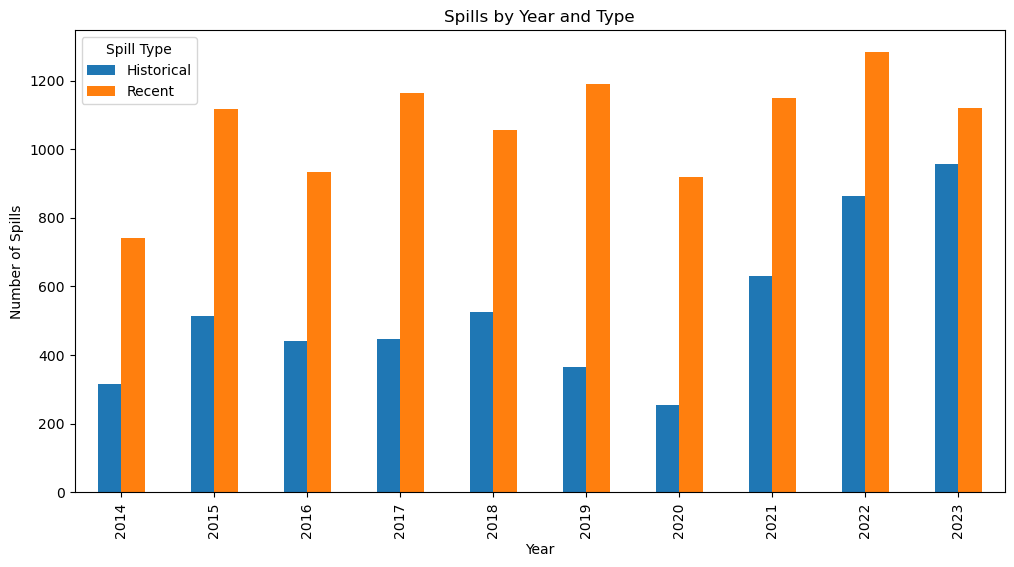

In [8]:
import matplotlib.pyplot as plt

# Compare Spill Trends Over Time
spills_by_year = spills_gdf.groupby(['Report Year', 'Spill Type']).size().unstack()
spills_by_year.plot(kind='bar', figsize=(12,6), title='Spills by Year and Type')
plt.xlabel('Year')
plt.ylabel('Number of Spills')
plt.legend(title='Spill Type')
plt.show()

In [9]:

# Operator Performance Analysis
operator_analysis = spills_gdf.groupby(['Operator', 'Spill Type'])['Report Delay (Days)'].mean().unstack()
operator_analysis['Total Spills'] = spills_gdf.groupby('Operator').size()
operator_analysis = operator_analysis.sort_values(by='Total Spills', ascending=False)
print(operator_analysis.head(10))


Spill Type                                  Historical     Recent  \
Operator                                                            
NOBLE ENERGY INC                              1.901973   1.435644   
KERR MCGEE OIL & GAS ONSHORE LP               6.485938  11.784062   
PDC ENERGY INC                                3.483728   2.366071   
CAERUS PICEANCE LLC                          10.162791   1.018735   
BONANZA CREEK ENERGY OPERATING COMPANY LLC   91.725000   1.138648   
CHEVRON USA INC                             251.076923   2.180723   
KP KAUFFMAN COMPANY INC                      62.929412   9.054598   
HIGHPOINT OPERATING CORPORATION               0.937500   0.941011   
LARAMIE ENERGY LLC                           23.833333   1.713467   
CRESTONE PEAK RESOURCES OPERATING LLC         1.804688   0.926724   

Spill Type                                  Total Spills  
Operator                                                  
NOBLE ENERGY INC                                    2

In [10]:
# Operator comparison of historical vs recent spills
operator_spill_type = spills_gdf.groupby(['Operator', 'Spill Type']).size().unstack()
operator_spill_type['Total Spills'] = operator_spill_type.sum(axis=1)
print(operator_spill_type.sort_values(by='Total Spills', ascending=False).head(10))


Spill Type                                  Historical  Recent  Total Spills
Operator                                                                    
NOBLE ENERGY INC                                1571.0   606.0        2177.0
KERR MCGEE OIL & GAS ONSHORE LP                 1280.0   778.0        2058.0
PDC ENERGY INC                                   676.0   448.0        1124.0
CAERUS PICEANCE LLC                              129.0   854.0         983.0
BONANZA CREEK ENERGY OPERATING COMPANY LLC        40.0   577.0         617.0
CHEVRON USA INC                                   52.0   415.0         467.0
KP KAUFFMAN COMPANY INC                           85.0   348.0         433.0
HIGHPOINT OPERATING CORPORATION                   32.0   356.0         388.0
LARAMIE ENERGY LLC                                24.0   349.0         373.0
CRESTONE PEAK RESOURCES OPERATING LLC            128.0   232.0         360.0


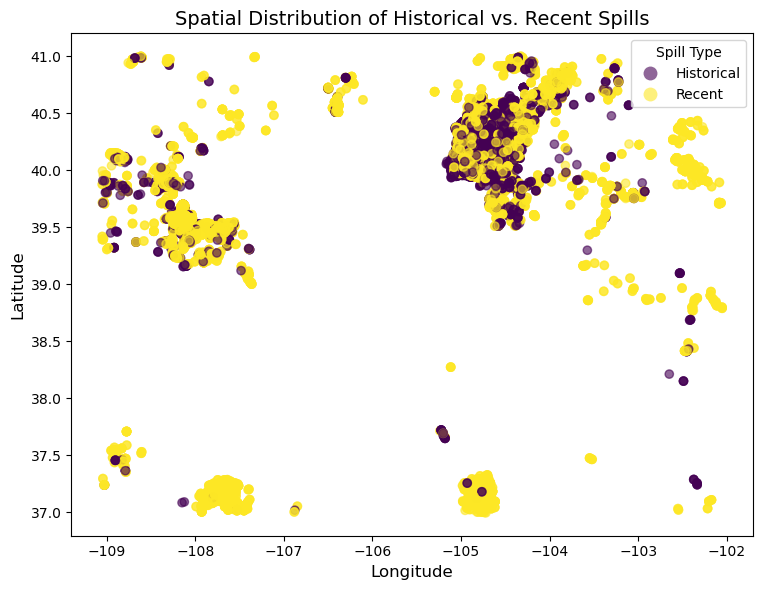

In [11]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Ensure spills_gdf is already a GeoDataFrame with the necessary data
# spills_gdf = gpd.GeoDataFrame(...)

# Create a plot for the spatial distribution of spills
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the GeoDataFrame with optimizations
spills_gdf.plot(
    ax=ax,
    marker='o', 
    alpha=0.6,  # Adjust transparency for better visibility
    column='Spill Type', 
    legend=True, 
    legend_kwds={'title': "Spill Type"},  # Correctly specify the legend title
    cmap='viridis'  # Use a colormap for better visual distinction
)

# Set plot title and labels
ax.set_title('Spatial Distribution of Historical vs. Recent Spills', fontsize=14)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()


In [12]:
# Add a column to indicate whether the spill occurred before or after 2020
spills_gdf['Period'] = spills_gdf['Report Year'].apply(lambda x: 'Before 2020' if x < 2020 else '2020 and After')

# Group by the new period column and calculate the mean response time
response_time_summary = spills_gdf.groupby('Period')['Report Delay (Days)'].describe()
print(response_time_summary)

                 count       mean         std  min  25%  50%  75%     max
Period                                                                   
2020 and After  7177.0   6.924342  124.965839  0.0  0.0  1.0  1.0  9261.0
Before 2020     8813.0  12.117554  124.705876  0.0  0.0  1.0  2.0  5681.0


T-Statistic: 2.6161
P-Value: 0.0089
The difference in response time is statistically significant.


<Axes: title={'center': 'Report Delay (Days)'}, xlabel='Period'>

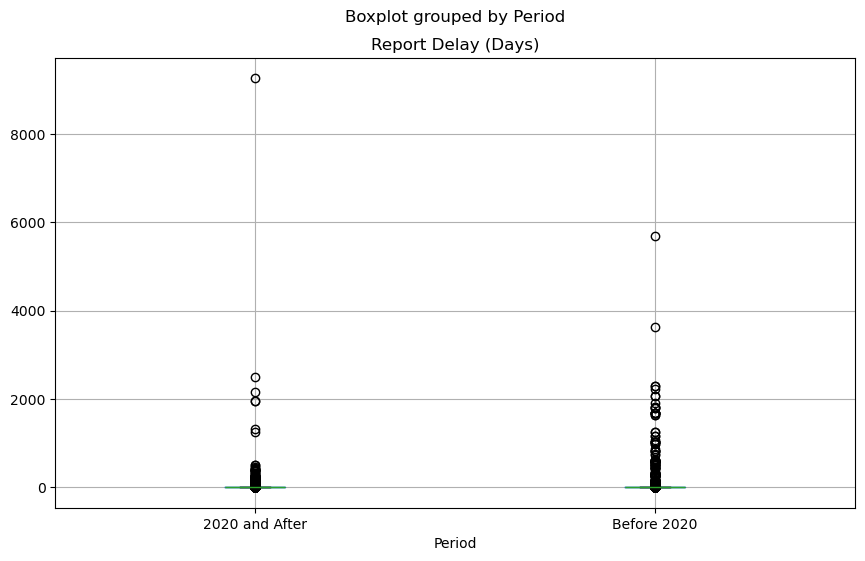

In [13]:
# t-test for the difference in response time before and after 2020
from scipy.stats import ttest_ind

before_2020 = spills_gdf[spills_gdf['Period'] == 'Before 2020']['Report Delay (Days)']
after_2020 = spills_gdf[spills_gdf['Period'] == '2020 and After']['Report Delay (Days)']

t_stat, p_value = ttest_ind(before_2020, after_2020, equal_var=False)
print(f'T-Statistic: {t_stat:.4f}')
print(f'P-Value: {p_value:.4f}')

# Check if the difference is statistically significant
if p_value < 0.05:
    print('The difference in response time is statistically significant.')
else:
    print('The difference in response time is not statistically significant.')
    
# Create a plot for the response time distribution before and after 2020
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the response time distribution for each period
spills_gdf.boxplot(column='Report Delay (Days)', by='Period', ax=ax)




In [14]:
# Add a column to indicate whether the spill occurred before or after 2020 for historical and recent spills
historical_spills['Period'] = historical_spills['Report Year'].apply(lambda x: 'Before 2020' if x < 2020 else '2020 and After')
recent_spills['Period'] = recent_spills['Report Year'].apply(lambda x: 'Before 2020' if x < 2020 else '2020 and After')

# Historical Spills Analysis
historical_report_delay_summary = historical_spills['Report Delay (Days)'].describe()
print("Historical Spills Report Delay Summary:")
print(historical_report_delay_summary)

# Recent Spills Analysis
recent_report_delay_summary = recent_spills['Report Delay (Days)'].describe()
print("\nRecent Spills Report Delay Summary:")
print(recent_report_delay_summary)

# Historical Spills Response Time Summary
historical_response_time_summary = historical_spills.groupby('Period')['Report Delay (Days)'].describe()
print("\nHistorical Spills Response Time Summary:")
print(historical_response_time_summary)

# Recent Spills Response Time Summary
recent_response_time_summary = recent_spills.groupby('Period')['Report Delay (Days)'].describe()
print("\nRecent Spills Response Time Summary:")
print(recent_response_time_summary)

Historical Spills Report Delay Summary:
count    5312.000000
mean       21.490023
std       205.615913
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max      9261.000000
Name: Report Delay (Days), dtype: float64

Recent Spills Report Delay Summary:
count    10678.000000
mean         3.964506
std         46.997749
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max       2232.000000
Name: Report Delay (Days), dtype: float64

Historical Spills Response Time Summary:
                 count       mean         std  min  25%  50%  75%     max
Period                                                                   
2020 and After  2705.0  13.533087  200.352339  0.0  0.0  0.0  1.0  9261.0
Before 2020     2607.0  29.746068  210.659491  0.0  0.0  1.0  2.0  5681.0

Recent Spills Response Time Summary:
                 count      mean        std  min  25%  50%  75%     max
Period                                         

/home/dadams/miniconda3/envs/spatial_env2/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/dadams/miniconda3/envs/spatial_env2/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)



Historical Spills T-Statistic: 2.8723
Historical Spills P-Value: 0.0041
The difference in response time for historical spills is statistically significant.

Recent Spills T-Statistic: 2.1457
Recent Spills P-Value: 0.0319
The difference in response time for recent spills is statistically significant.


<Axes: title={'center': 'Report Delay (Days)'}, xlabel='Period'>

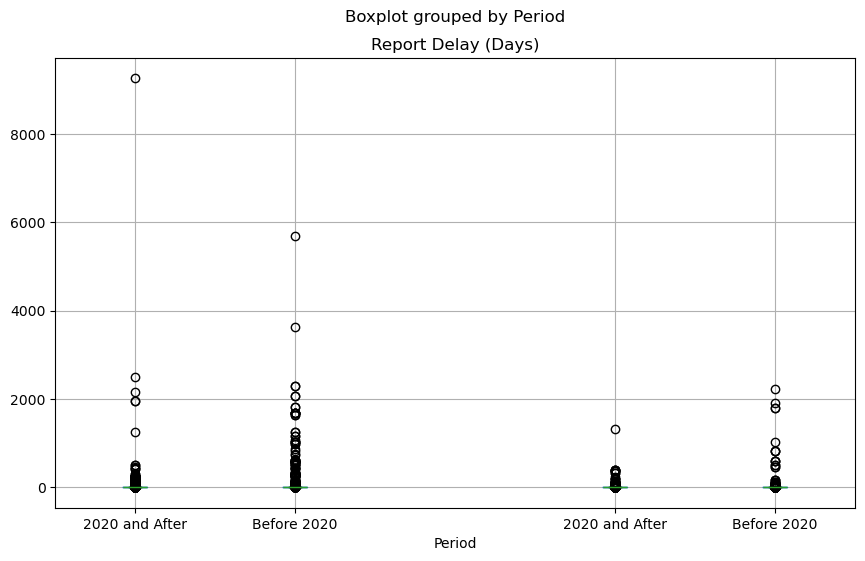

In [15]:
# t-test for the difference in response time before and after 2020 for historical spills
historical_before_2020 = historical_spills[historical_spills['Period'] == 'Before 2020']['Report Delay (Days)']
historical_after_2020 = historical_spills[historical_spills['Period'] == '2020 and After']['Report Delay (Days)']

t_stat, p_value = ttest_ind(historical_before_2020, historical_after_2020, equal_var=False)
print(f'\nHistorical Spills T-Statistic: {t_stat:.4f}')
print(f'Historical Spills P-Value: {p_value:.4f}')

# Check if the difference is statistically significant for historical spills
if p_value < 0.05:
    print('The difference in response time for historical spills is statistically significant.')
else:
    print('The difference in response time for historical spills is not statistically significant.')
    
# t-test for the difference in response time before and after 2020 for recent spills
recent_before_2020 = recent_spills[recent_spills['Period'] == 'Before 2020']['Report Delay (Days)']
recent_after_2020 = recent_spills[recent_spills['Period'] == '2020 and After']['Report Delay (Days)']

t_stat, p_value = ttest_ind(recent_before_2020, recent_after_2020, equal_var=False)
print(f'\nRecent Spills T-Statistic: {t_stat:.4f}')
print(f'Recent Spills P-Value: {p_value:.4f}')

# Check if the difference is statistically significant for recent spills
if p_value < 0.05:
    print('The difference in response time for recent spills is statistically significant.')
else:
    print('The difference in response time for recent spills is not statistically significant.')
    
# Create a plot for the response time distribution before and after 2020 for historical and recent spills
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the response time distribution for historical spills
historical_spills.boxplot(column='Report Delay (Days)', by='Period', ax=ax, positions=[1, 2])

# Plot the response time distribution for recent spills
recent_spills.boxplot(column='Report Delay (Days)', by='Period', ax=ax, positions=[4, 5])


In [18]:
# list operator names
operator_names = operator_analysis.index.tolist()


In [19]:
print (operator_names)


['NOBLE ENERGY INC', 'KERR MCGEE OIL & GAS ONSHORE LP', 'PDC ENERGY INC', 'CAERUS PICEANCE LLC', 'BONANZA CREEK ENERGY OPERATING COMPANY LLC', 'CHEVRON USA INC', 'KP KAUFFMAN COMPANY INC', 'HIGHPOINT OPERATING CORPORATION', 'LARAMIE ENERGY LLC', 'CRESTONE PEAK RESOURCES OPERATING LLC', 'PIONEER NATURAL RESOURCES USA INC', 'EXTRACTION OIL & GAS INC', 'TEP ROCKY MOUNTAIN LLC', 'WHITING OIL & GAS CORPORATION', 'FOUNDATION ENERGY MANAGEMENT LLC', 'BP AMERICA PRODUCTION COMPANY', 'KERR MCGEE GATHERING LLC', 'DCP OPERATING COMPANY LP', 'GREAT WESTERN OPERATING COMPANY LLC', 'WPX ENERGY ROCKY MOUNTAIN LLC', 'EVERGREEN NATURAL RESOURCES LLC', 'ENCANA OIL & GAS (USA) INC', 'SIMCOE LLC', 'DCP MIDSTREAM LP', 'XTO ENERGY INC', 'SANDRIDGE EXPLORATION & PRODUCTION LLC', 'BARRETT CORPORATION* BILL', 'AUGUSTUS ENERGY RESOURCES LLC', 'SRC ENERGY INC', 'PETROSHARE CORPORATION', 'SYNERGY RESOURCES CORPORATION', 'URSA OPERATING COMPANY LLC', 'FUNDARE RESOURCES OPERATING COMPANY LLC', 'KINDER MORGAN CO2 CO